# Transient free-surface Full-Stokes bed-seed test

This notebook begins [Issue #24](https://github.com/bradlipovsky/allan-hills-stratigraphy/issues/24). It asks a deliberately narrow question: can a smooth, finite-duration bed displacement dynamically make a steep or overturned material-layer seed near the depths of the ALHIC1901 folds?

This is a numerical positive-control experiment, not a claim that rapid tectonic uplift occurred beneath Allan Hills. The imposed sinusoidal bed motion is an explicit mechanical end member. Material layers begin horizontal and are moved only by the computed velocity; no interior age packet, fold, discontinuity, reflection, clipping, or remapping is imposed.

## Governing problem and boundary conditions

At each time, the model solves the quasi-static, incompressible Full-Stokes equations

$$-
\nabla\!\cdot\boldsymbol\sigma=\rho\mathbf g,
\qquad \nabla\!\cdot\mathbf u=0,
\qquad
\boldsymbol\sigma=2\eta\dot{\boldsymbol\varepsilon}-p\mathbf I,
$$

with the full symmetric strain-rate tensor and Glen exponent $n=3$,

$$
\eta=\tfrac12 A^{-1/n}
\left(\dot\varepsilon_e^2+\dot\varepsilon_0^2\right)^{(1-n)/(2n)}.
$$

Coordinates are $x$ horizontally along flow and $z$ vertically upward; all lengths are metres and time is years. The 500 m periodic cell has initial thickness 160 m and a mean surface slope of 0.03 radians, represented by the along-flow component of gravity. The bed is no-slip and moves vertically with

$$
b(x,t)=B(t)\cos(2\pi x/L),\qquad
B(t)=\frac{B_{max}}{2}\left[1-\cos(\pi t/T_b)\right]
$$

for $0<t<T_b$, after which it is fixed. Here $B_{max}=15$ m and $T_b=1000$ yr, giving a maximum vertical bed speed of 0.0236 m/yr. The upper boundary is traction-free. There is no surface mass balance in this experiment. The free surface evolves as

$$
\frac{\partial h}{\partial t}=w_s-u_s\frac{\partial h}{\partial x}.
$$

An arbitrary-Lagrangian--Eulerian mesh follows both boundaries. Glen softness is calibrated so that the corresponding flat, 160 m slab has a 0.0138 m/yr surface speed. A strain-rate floor of $10^{-10}$ yr$^{-1}$ regularizes viscosity only; it does not constrain the layer geometry.

In [1]:
import logging
import warnings

warnings.filterwarnings("ignore", message="Unable to import recommended hash")
import firedrake as fd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

logging.getLogger("tsfc").setLevel(logging.ERROR)

L, H = 500.0, 160.0
NX, NZ = 24, 8
RHO, GRAVITY, SURFACE_SLOPE = 917.0, 9.81, 0.03
GLEN_N = 3.0
REFERENCE_VISCOSITY = 2.5e8  # Pa yr
STRAIN_FLOOR = 1.0e-10        # yr^-1
BED_MAX, BED_RAMP = 15.0, 1000.0
DT, FINAL_TIME = 50.0, 1800.0

driving_stress_gradient = RHO * GRAVITY * np.sin(SURFACE_SLOPE)
reference_surface_speed = (
    driving_stress_gradient * H**2 / (2 * REFERENCE_VISCOSITY)
)
softness = reference_surface_speed * (GLEN_N + 1) / (
    2 * driving_stress_gradient**GLEN_N * H**(GLEN_N + 1)
)

print(f"Reference surface speed: {reference_surface_speed:.4f} m/yr")
print(f"Maximum bed speed: {0.5 * np.pi * BED_MAX / BED_RAMP:.4f} m/yr")
print(f"Mesh: {NX} x {NZ}; time step: {DT:.0f} yr; final time: {FINAL_TIME:.0f} yr")

Reference surface speed: 0.0138 m/yr
Maximum bed speed: 0.0236 m/yr
Mesh: 24 x 8; time step: 50 yr; final time: 1800 yr


## Full-Stokes and moving-boundary implementation

The periodic $P_2$--$P_1$ Taylor--Hood discretization solves horizontal velocity, vertical velocity, and pressure together. Pressure is defined only up to a constant, which is removed before plotting. The free surface uses a centered periodic slope and forward time integration. A 50 yr step is used because a 100 yr step did not reliably resolve the shutdown of the bed motion; that is a numerical time-step observation, not an added physical constraint.

In [2]:
mesh = fd.PeriodicRectangleMesh(NX, NZ, L, H, direction="x")
reference_coordinates = mesh.coordinates.dat.data_ro.copy()
reference_x = reference_coordinates[:, 0].copy()
sigma_coordinate = reference_coordinates[:, 1] / H

velocity_space = fd.VectorFunctionSpace(mesh, "CG", 2)
pressure_space = fd.FunctionSpace(mesh, "CG", 1)
mixed_space = velocity_space * pressure_space
solution = fd.Function(mixed_space, name="velocity_pressure")
velocity_symbol, pressure_symbol = fd.split(solution)
test_velocity, test_pressure = fd.TestFunctions(mixed_space)

strain_rate = fd.sym(fd.grad(velocity_symbol))
effective_strain_rate = fd.sqrt(
    0.5 * fd.inner(strain_rate, strain_rate) + STRAIN_FLOOR**2
)
viscosity = (
    0.5 * softness ** (-1 / GLEN_N)
    * effective_strain_rate ** ((1 - GLEN_N) / GLEN_N)
)
body_force = fd.Constant(
    (
        RHO * GRAVITY * np.sin(SURFACE_SLOPE),
        -RHO * GRAVITY * np.cos(SURFACE_SLOPE),
    )
)
residual = (
    2 * viscosity * fd.inner(strain_rate, fd.sym(fd.grad(test_velocity)))
    - pressure_symbol * fd.div(test_velocity)
    - test_pressure * fd.div(velocity_symbol)
    - fd.dot(body_force, test_velocity)
) * fd.dx

x_symbol, z_symbol = fd.SpatialCoordinate(mesh)
bed_speed = fd.Constant(0.0)
bed_velocity = fd.as_vector(
    (0.0, bed_speed * fd.cos(2 * np.pi * x_symbol / L))
)
bed_boundary = fd.DirichletBC(mixed_space.sub(0), bed_velocity, 1)
solver_parameters = {
    "snes_type": "newtonls",
    "snes_linesearch_type": "bt",
    "snes_rtol": 1.0e-8,
    "snes_max_it": 100,
    "ksp_type": "preonly",
    "pc_type": "lu",
    "pc_factor_mat_solver_type": "mumps",
}

def slab_velocity(height):
    return 2 * softness * driving_stress_gradient**GLEN_N / (GLEN_N + 1) * (
        H ** (GLEN_N + 1) - (H - height) ** (GLEN_N + 1)
    )

solution.sub(0).interpolate(fd.as_vector((slab_velocity(z_symbol), 0.0)))
solution.sub(1).interpolate(
    RHO * GRAVITY * np.cos(SURFACE_SLOPE) * (H - z_symbol)
)

# Store the surface at the horizontal top-mesh nodes so point
# evaluation remains strictly inside the piecewise-linear boundary.
x_surface = np.linspace(0.0, L, NX, endpoint=False)
surface = np.full_like(x_surface, H)

def periodic_interpolate(points, values):
    return np.interp(
        np.mod(points, L),
        np.r_[x_surface, L],
        np.r_[values, values[0]],
    )

def bed_history(time):
    if time >= BED_RAMP:
        return BED_MAX, 0.0
    phase = np.pi * time / BED_RAMP
    return (
        0.5 * BED_MAX * (1 - np.cos(phase)),
        0.5 * BED_MAX * np.pi / BED_RAMP * np.sin(phase),
    )

def update_mesh(amplitude):
    bed_at_nodes = amplitude * np.cos(2 * np.pi * reference_x / L)
    top_at_nodes = periodic_interpolate(reference_x, surface)
    mesh.coordinates.dat.data[:, 0] = reference_x
    mesh.coordinates.dat.data[:, 1] = (
        bed_at_nodes + sigma_coordinate * (top_at_nodes - bed_at_nodes)
    )
    mesh.clear_spatial_index()

def points_just_inside(x_points, z_points):
    x_safe = np.mod(np.asarray(x_points, dtype=float), L)
    x_safe[np.isclose(x_safe, 0.0)] = 1.0e-5
    return np.column_stack((x_safe, np.asarray(z_points) - 1.0e-4))

## Material-layer experiment

Eleven initially horizontal layers are represented by Lagrangian particles. Initial elevations of 7--20 m correspond to core depths of 140--153 m, the interval of immediate interest. Particle horizontal coordinates remain unwrapped, so tangent reversal can be detected without ambiguity at the periodic seam.

In [3]:
layer_heights = np.array([7, 10, 15, 20, 25, 30, 40, 60, 80, 100, 130], dtype=float)
particles_per_layer = 64
initial_particle_x = np.tile(
    np.linspace(0.0, L, particles_per_layer, endpoint=False),
    len(layer_heights),
)
particle_x = initial_particle_x.copy()
particle_z = np.repeat(layer_heights, particles_per_layer).astype(float)

snapshot_times = [0.0, 500.0, 1000.0, FINAL_TIME]
snapshots = {}
history = []

times = np.arange(0.0, FINAL_TIME + 0.5 * DT, DT)
for step, time in enumerate(times):
    amplitude, amplitude_rate = bed_history(time)
    update_mesh(amplitude)
    bed_speed.assign(amplitude_rate)
    fd.solve(
        residual == 0,
        solution,
        bcs=[bed_boundary],
        solver_parameters=solver_parameters,
    )
    velocity, pressure = solution.subfunctions

    bed_on_surface_grid = amplitude * np.cos(2 * np.pi * x_surface / L)
    volume = L * np.mean(surface - bed_on_surface_grid)
    history.append(
        {
            "time": time,
            "bed_amplitude": amplitude,
            "surface_relief": np.ptp(surface),
            "volume_error": volume / (L * H) - 1,
        }
    )

    if np.any(np.isclose(time, snapshot_times)):
        snapshots[float(time)] = {
            "surface": surface.copy(),
            "bed_amplitude": amplitude,
            "particle_x": particle_x.copy(),
            "particle_z": particle_z.copy(),
        }

    if step == len(times) - 1:
        break

    surface_points = points_just_inside(
        x_surface, periodic_interpolate(x_surface, surface)
    )
    surface_velocity = np.asarray(
        velocity.at(surface_points, tolerance=1.0e-7)
    )
    dx_surface = L / len(x_surface)
    surface_slope = (
        np.roll(surface, -1) - np.roll(surface, 1)
    ) / (2 * dx_surface)
    surface += DT * (
        surface_velocity[:, 1] - surface_velocity[:, 0] * surface_slope
    )

    particle_points = points_just_inside(particle_x, particle_z + 1.0e-4)
    particle_velocity = np.asarray(
        velocity.at(particle_points, tolerance=1.0e-7)
    )
    particle_x += DT * particle_velocity[:, 0]
    particle_z += DT * particle_velocity[:, 1]

history = pd.DataFrame(history)
print(f"Completed {len(times)} Full-Stokes solves.")
print(f"Maximum absolute volume residual: {history.volume_error.abs().max():.2e}")

Completed 37 Full-Stokes solves.
Maximum absolute volume residual: 1.61e-05


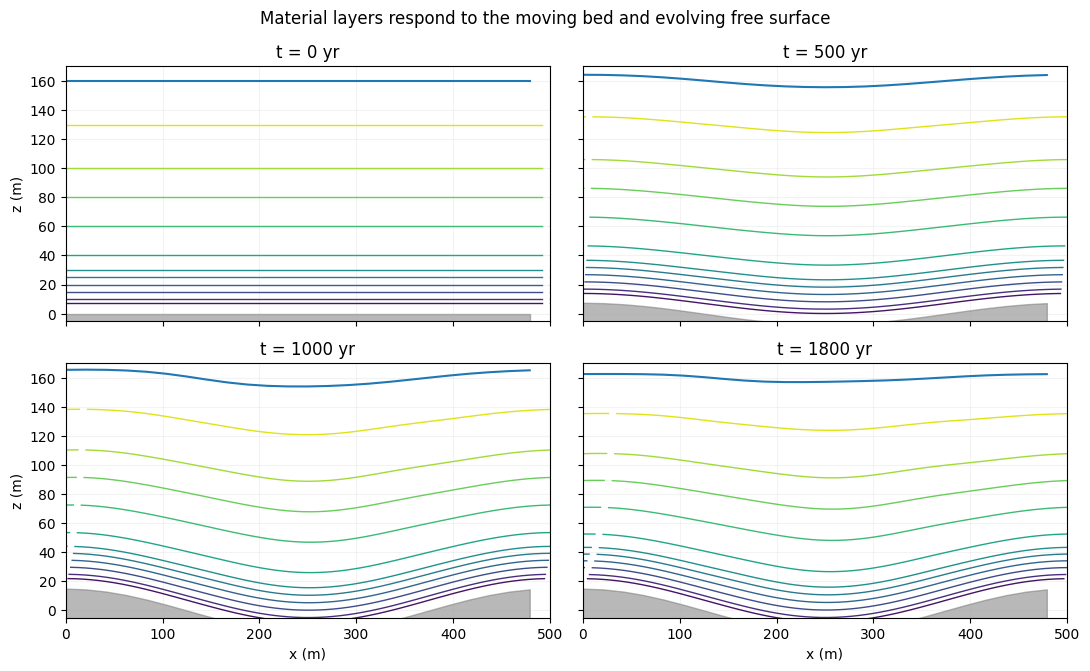

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.8), sharex=True, sharey=True)
colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(layer_heights)))

for axis, time in zip(axes.flat, snapshot_times):
    state = snapshots[float(time)]
    for index, color in enumerate(colors):
        selection = slice(
            index * particles_per_layer,
            (index + 1) * particles_per_layer,
        )
        xx = state["particle_x"][selection]
        zz = state["particle_z"][selection]
        shift = L * np.round((np.mean(xx) - 0.5 * L) / L)
        xx = xx - shift
        for periodic_shift in (-L, 0.0, L):
            axis.plot(xx + periodic_shift, zz, color=color, lw=1.0)

    bed = state["bed_amplitude"] * np.cos(2 * np.pi * x_surface / L)
    axis.fill_between(x_surface, -20, bed, color="0.45", alpha=0.5)
    axis.plot(x_surface, state["surface"], color="tab:blue", lw=1.5)
    axis.set_title(f"t = {time:.0f} yr")
    axis.set_xlim(0, L)
    axis.set_ylim(-5, 170)
    axis.grid(alpha=0.15)

axes[1, 0].set_xlabel("x (m)")
axes[1, 1].set_xlabel("x (m)")
axes[0, 0].set_ylabel("z (m)")
axes[1, 0].set_ylabel("z (m)")
fig.suptitle("Material layers respond to the moving bed and evolving free surface")
fig.tight_layout()
plt.show()

Layer tangents are computed from the periodic displacement field, not from a re-sorted curve. A segment is overturned when $\partial x/\partial X<0$, where $X$ is its initial horizontal material coordinate. Dip is reported from 0° for horizontal to values above 90° after overturning.

In [5]:
metrics = []
material_spacing = L / particles_per_layer
for index, height in enumerate(layer_heights):
    selection = slice(
        index * particles_per_layer,
        (index + 1) * particles_per_layer,
    )
    displacement = (
        particle_x[selection] - initial_particle_x[selection]
    )
    z_layer = particle_z[selection]
    dx_dX = 1 + (
        np.roll(displacement, -1) - np.roll(displacement, 1)
    ) / (2 * material_spacing)
    dz_dX = (
        np.roll(z_layer, -1) - np.roll(z_layer, 1)
    ) / (2 * material_spacing)
    inclination = np.degrees(np.arctan2(np.abs(dz_dX), dx_dX))
    metrics.append(
        {
            "initial z (m)": height,
            "initial core depth (m)": H - height,
            "final relief (m)": np.ptp(z_layer),
            "maximum dip (deg)": np.max(inclination),
            "overturned segments": np.count_nonzero(dx_dX < 0),
            "minimum dx/dX": np.min(dx_dX),
        }
    )

metrics = pd.DataFrame(metrics)
display(metrics.round(3))

overturned_total = int(metrics["overturned segments"].sum())
deepest = metrics[metrics["initial core depth (m)"] >= 140]
print(
    f"Target-depth layers: maximum relief = {deepest['final relief (m)'].max():.2f} m; "
    f"maximum dip = {deepest['maximum dip (deg)'].max():.1f} degrees."
)
if overturned_total:
    print(f"Result: {overturned_total} material segments overturn.")
else:
    print("Result: no material tangent rotates through vertical in this run.")

,initial z (m),initial core depth (m),final relief (m),maximum dip (deg),overturned segments,minimum dx/dX
0,7.0,153.0,29.716,10.522,0,0.956
1,10.0,150.0,29.543,10.422,0,0.946
2,15.0,145.0,29.152,10.219,0,0.934
3,20.0,140.0,28.620,9.964,0,0.930
4,25.0,135.0,27.995,9.666,0,0.927
5,30.0,130.0,27.341,9.369,0,0.926
6,40.0,120.0,25.887,8.756,0,0.925
7,60.0,100.0,22.822,7.621,0,0.929
8,80.0,80.0,19.785,6.576,0,0.930
9,100.0,60.0,16.776,5.648,0,0.928


Target-depth layers: maximum relief = 29.72 m; maximum dip = 10.5 degrees.
Result: no material tangent rotates through vertical in this run.


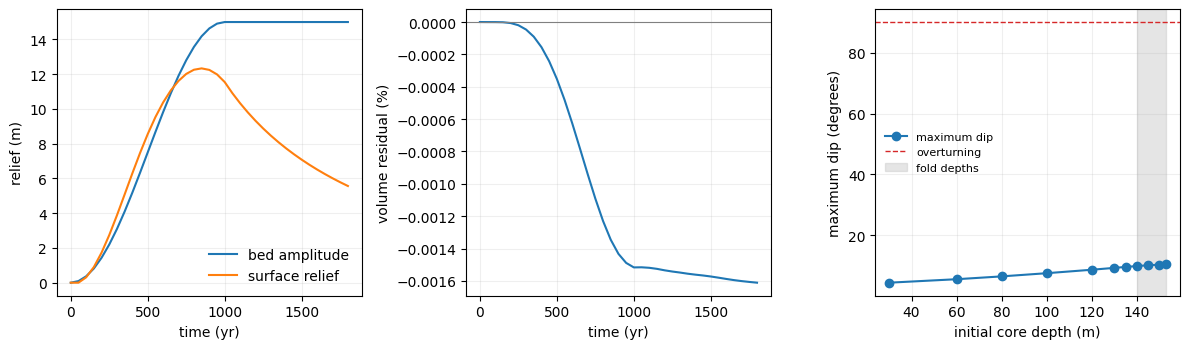

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
axes[0].plot(history.time, history.bed_amplitude, label="bed amplitude")
axes[0].plot(history.time, history.surface_relief, label="surface relief")
axes[0].set(xlabel="time (yr)", ylabel="relief (m)")
axes[0].legend(frameon=False)

axes[1].plot(history.time, 100 * history.volume_error)
axes[1].axhline(0, color="0.5", lw=0.8)
axes[1].set(xlabel="time (yr)", ylabel="volume residual (%)")

axes[2].plot(
    metrics["initial core depth (m)"],
    metrics["maximum dip (deg)"],
    "o-",
    label="maximum dip",
)
axes[2].axhline(90, color="tab:red", ls="--", lw=1, label="overturning")
axes[2].axvspan(140, 153, color="0.8", alpha=0.5, label="fold depths")
axes[2].set(xlabel="initial core depth (m)", ylabel="maximum dip (degrees)")
axes[2].legend(frameon=False, fontsize=8)

for axis in axes:
    axis.grid(alpha=0.2)
fig.tight_layout()
plt.show()

## Flow and Waddington diagnostics at the final time

The six panels show the two velocity components, the two shear-gradient terms, the pure-shear denominator $D=\partial u/\partial x-\partial w/\partial z$, and the Waddington--Bolzan--Alley shear parameter

$$S=\frac{\partial u/\partial z+\partial w/\partial x}{D}.$$

$S$ is masked where $|D|<10^{-7}$ yr$^{-1}$ because a large ratio there reflects division by an insignificant pure-shear rate, not strong shear. This diagnostic does not feed back into the solve.

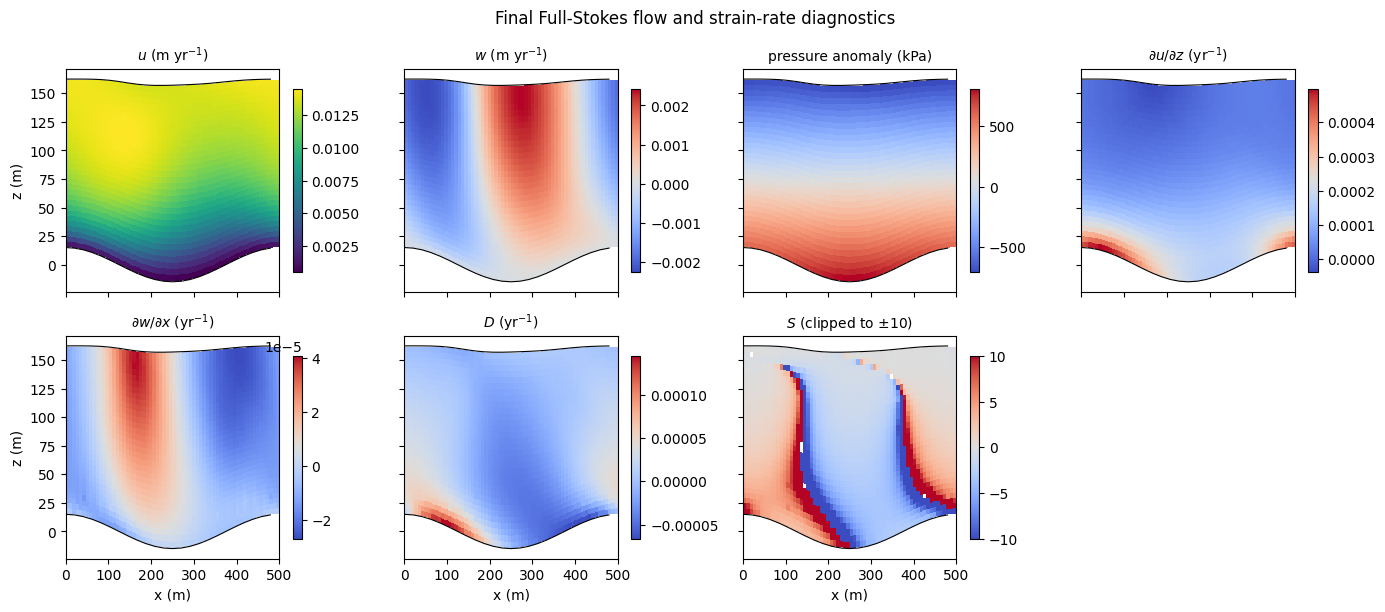

In [7]:
diagnostic_space = fd.FunctionSpace(mesh, "DG", 1)
du_dx = fd.project(velocity[0].dx(0), diagnostic_space)
du_dz = fd.project(velocity[0].dx(1), diagnostic_space)
dw_dx = fd.project(velocity[1].dx(0), diagnostic_space)
dw_dz = fd.project(velocity[1].dx(1), diagnostic_space)

x_query = np.linspace(L / 128, L - L / 128, 64)
sigma_query = np.linspace(0.02, 0.98, 32)
final_amplitude, _ = bed_history(FINAL_TIME)
bed_query = final_amplitude * np.cos(2 * np.pi * x_query / L)
surface_query = periodic_interpolate(x_query, surface)
X_query = np.tile(x_query, (len(sigma_query), 1))
Z_query = bed_query[None, :] + sigma_query[:, None] * (
    surface_query - bed_query
)[None, :]
query_points = np.column_stack((X_query.ravel(), Z_query.ravel()))

def sample(function):
    return np.asarray(function.at(query_points, tolerance=1.0e-7)).reshape(
        Z_query.shape
    )

uv_values = np.asarray(velocity.at(query_points, tolerance=1.0e-7)).reshape(
    Z_query.shape + (2,)
)
du_dx_values = sample(du_dx)
du_dz_values = sample(du_dz)
dw_dx_values = sample(dw_dx)
dw_dz_values = sample(dw_dz)
D_values = du_dx_values - dw_dz_values
G_values = du_dz_values + dw_dx_values
S_values = np.where(np.abs(D_values) >= 1.0e-7, G_values / D_values, np.nan)

pressure_values = np.asarray(
    pressure.at(query_points, tolerance=1.0e-7)
).reshape(Z_query.shape)
pressure_values -= np.nanmean(pressure_values)

fields = [
    (uv_values[..., 0], r"$u$ (m yr$^{-1}$)", "viridis"),
    (uv_values[..., 1], r"$w$ (m yr$^{-1}$)", "coolwarm"),
    (pressure_values / 1000, "pressure anomaly (kPa)", "coolwarm"),
    (du_dz_values, r"$\partial u/\partial z$ (yr$^{-1}$)", "coolwarm"),
    (dw_dx_values, r"$\partial w/\partial x$ (yr$^{-1}$)", "coolwarm"),
    (D_values, r"$D$ (yr$^{-1}$)", "coolwarm"),
    (np.clip(S_values, -10, 10), r"$S$ (clipped to $\pm10$)", "coolwarm"),
]

fig, axes = plt.subplots(2, 4, figsize=(14, 6.2), sharex=True, sharey=True)
for axis, (values, title, cmap) in zip(axes.flat, fields):
    image = axis.pcolormesh(X_query, Z_query, values, shading="auto", cmap=cmap)
    axis.plot(x_surface, surface, color="k", lw=0.8)
    axis.plot(x_surface, final_amplitude * np.cos(2 * np.pi * x_surface / L), color="k", lw=0.8)
    axis.set_title(title, fontsize=10)
    fig.colorbar(image, ax=axis, shrink=0.82)
axes.flat[-1].axis("off")
for axis in axes[1]:
    axis.set_xlabel("x (m)")
for axis in axes[:, 0]:
    axis.set_ylabel("z (m)")
fig.suptitle("Final Full-Stokes flow and strain-rate diagnostics")
fig.tight_layout()
plt.show()

## Interpretation and next calculation

This run is intentionally a forward test, not a fit. Its forcing is dynamically explicit and its stratigraphy remains Lagrangian. The 500 m-wavelength event creates 29.7 m of relief in the target-depth layers but only 10.5° maximum dip, and no segment overturns. It therefore fails the first sign test by a wide margin: large layer relief is not equivalent to the steep limb that later shear would need. This rejects this broad bed event as the ALHIC1901 seed; it does not reject narrower bed forcing.

Increasing post-event time alone is not yet justified because the present moving-mesh solve has only been verified through 1800 yr. The next calculation should first establish time-step and mesh convergence, improve nonlinear robustness on more deformed domains, and sweep event width. The natural quantitative question is whether a narrower perturbation can reach 90° at 140--153 m core depth without requiring still larger bed displacement.

Even a numerical positive result would face a physical plausibility problem: 15 m of coherent sinusoidal bed displacement in 1000 yr, with centimetre-per-year vertical motion, is extreme for bedrock uplift. The useful outcome is therefore the required seed geometry and strain, which can be compared with less literal mechanisms such as advection over fixed topography or surface-mass-balance forcing. This single-period experiment cannot produce the observed three-fold ALHIC1901 sequence by construction. A later experiment must enlarge the domain or use multiple dynamically generated rumples, then attach deposition ages and test the three observed peak depths.